In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

print("All good!")

All good!


In [2]:
import nflreadpy as nfl

# NFL 4th Down Decision Model

## Overview
This project is meant to replicate the kind of analysis performed by NFL analytics teams to evaluate 4th down decision-making. Using play-by-play from the 2019-2025 seasons, we build a logistic regression model to predict 4th down conversion probability. Then, combining conversion probability with an expected win probability framework, we define a function that recommends the type of play call that optimizes win probability -- go for it, punt, or kick a field goal -- for any fourth down game situation.

## Key Questions
- How often do NFL coaches make the analytically optimal decision on 4th down?
- Which coaches are most and least aligned with data-driven recommendations?
- HOw does field position, score, and time remaining affect the right call?

## Phase 1: Loading data & scaling down to key columns
Play-by-play data was sourced from nflreadpy, a Python port of the nflverse data repository, available for free on Github. The dataset covered 7 NFL seasons and contains roughly 340,000 plays, with 372 columns tracking key information from down to score differential to time remaining to win probability at each point in the point. 

Key columns of interest:
- **down/ydstogo**: The down and distance situation
- **yardline_100**: field position of team with possession
- **score_differential**: possession team score minus defensive team score
- **game_seconds_remaining**: time left in the game
- **wp / wpa**: win probability before the play, and win probability added by the play
- **fourth_down_converted**: whether the 4th down attempt succeeded (1) or failed (0)

In [3]:
#Load seasons play-by-play data
pbp = nfl.load_pbp([2019, 2020, 2021, 2022, 2023, 2024, 2025])

#Load player game-level stats for multiple seasons
player_stats = nfl.load_player_stats([2019, 2020, 2021, 2022, 2023, 2024, 2025])

#Load all available team level stats
team_stats = nfl.load_team_stats(seasons=True)

#convert from Polars to pandas
pbp = pbp.to_pandas()

In [4]:
#(rows, columns)
print(pbp.shape)

#list column names
print(pbp.columns.tolist())

#sneak peak at first 5 rows of data. Add .to_string() to see all columns
pbp.head()

(342249, 372)
['play_id', 'game_id', 'old_game_id', 'home_team', 'away_team', 'season_type', 'week', 'posteam', 'posteam_type', 'defteam', 'side_of_field', 'yardline_100', 'game_date', 'quarter_seconds_remaining', 'half_seconds_remaining', 'game_seconds_remaining', 'game_half', 'quarter_end', 'drive', 'sp', 'qtr', 'down', 'goal_to_go', 'time', 'yrdln', 'ydstogo', 'ydsnet', 'desc', 'play_type', 'yards_gained', 'shotgun', 'no_huddle', 'qb_dropback', 'qb_kneel', 'qb_spike', 'qb_scramble', 'pass_length', 'pass_location', 'air_yards', 'yards_after_catch', 'run_location', 'run_gap', 'field_goal_result', 'kick_distance', 'extra_point_result', 'two_point_conv_result', 'home_timeouts_remaining', 'away_timeouts_remaining', 'timeout', 'timeout_team', 'td_team', 'td_player_name', 'td_player_id', 'posteam_timeouts_remaining', 'defteam_timeouts_remaining', 'total_home_score', 'total_away_score', 'posteam_score', 'defteam_score', 'score_differential', 'posteam_score_post', 'defteam_score_post', 'scor

,play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,out_of_bounds,home_opening_kickoff,qb_epa,xyac_epa,xyac_mean_yardage,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe
0,1.0,2019_01_ATL_MIN,2019090804,MIN,ATL,REG,1,NaN,NaN,NaN,...,0.0,0.0,-0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,36.0,2019_01_ATL_MIN,2019090804,MIN,ATL,REG,1,ATL,away,MIN,...,0.0,0.0,-0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,51.0,2019_01_ATL_MIN,2019090804,MIN,ATL,REG,1,ATL,away,MIN,...,0.0,0.0,-1.658763,NaN,NaN,NaN,NaN,NaN,0.486799,51.320082
3,79.0,2019_01_ATL_MIN,2019090804,MIN,ATL,REG,1,ATL,away,MIN,...,0.0,0.0,-0.538914,NaN,NaN,NaN,NaN,NaN,0.639994,-63.999379
4,100.0,2019_01_ATL_MIN,2019090804,MIN,ATL,REG,1,ATL,away,MIN,...,0.0,0.0,0.142138,NaN,NaN,NaN,NaN,NaN,0.933516,6.648362


In [5]:
#scale down columns just to ones we will use for 4th down recommendation model
key_cols = ["down", "ydstogo", "yardline_100", "play_type", "score_differential", "game_seconds_remaining", "wp", "wpa", "fourth_down_converted", "fourth_down_failed", "field_goal_result", "kick_distance", "posteam", "defteam"]

pbp_key = pbp[key_cols].copy()
pbp_key.head()

,down,ydstogo,yardline_100,play_type,score_differential,game_seconds_remaining,wp,wpa,fourth_down_converted,fourth_down_failed,field_goal_result,kick_distance,posteam,defteam
0,NaN,0.0,NaN,NaN,NaN,3600.0,0.433208,-0.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,0.0,35.0,kickoff,0.0,3600.0,0.433208,-0.000000,0.0,0.0,NaN,65.0,ATL,MIN
2,1.0,10.0,75.0,pass,0.0,3600.0,0.433208,-0.035015,0.0,0.0,NaN,NaN,ATL,MIN
3,2.0,18.0,83.0,run,0.0,3560.0,0.398193,-0.018435,0.0,0.0,NaN,NaN,ATL,MIN
4,3.0,14.0,79.0,run,0.0,3521.0,0.379757,0.018007,0.0,0.0,NaN,NaN,ATL,MIN


In [6]:
#yardline_100 from the perspective of the team with possession. Low yardline_100 = redzone
pbp[['posteam', 'yrdln', 'yardline_100']].dropna().query('yardline_100 < 10').head(10)

,posteam,yrdln,yardline_100
60,MIN,ATL 1,1.0
61,MIN,ATL 1,1.0
108,ATL,MIN 2,2.0
109,ATL,MIN 3,3.0
116,MIN,ATL 7,7.0
136,ATL,MIN 2,2.0
163,ATL,MIN 2,2.0
164,ATL,MIN 2,2.0
176,BAL,MIA 6,6.0
177,BAL,MIA 2,2.0


In [7]:
#limit to just 4th down plays
fourth_downs = pbp_key[
    (pbp_key["down"]==4) &
    (pbp_key["play_type"].isin(["pass", "run", "punt", "field_goal", "qb_scramble"]))
].copy()

print(f"Total 4th down plays {len(fourth_downs)}")
print(f"\nPlay type breakdown:")
print(fourth_downs["play_type"].value_counts())

Total 4th down plays 27667

Play type breakdown:
play_type
punt          15231
field_goal     6952
pass           3420
run            2064
Name: count, dtype: int64


In [8]:

#function to streamline classifying play type
def classify_decision(play_type):
    if play_type == 'punt':
        return 'Punt'
    elif play_type =='field_goal':
        return 'Field Goal'
    else:
        return 'Go For It'

fourth_downs['decision'] = fourth_downs['play_type'].apply(classify_decision) #runs classify_decision function on every row in play_type column and stores result

print(fourth_downs['decision'].value_counts()) #counts results in new decision column

decision
Punt          15231
Field Goal     6952
Go For It      5484
Name: count, dtype: int64


In [9]:
#function to classify field position
def field_pos(yardline_100):
    if pd.isna(yardline_100):
        return None
    elif yardline_100 > 60: 
        return 'Own Territory (own 40 and back)'
    elif yardline_100 > 40: 
        return 'Midfield (own 40 - opp 40)'
    elif yardline_100 > 20:
        return 'Opp Territory (opp 40-20)'
    else: 
        return 'Red Zone (opp 20 and in)'

fourth_downs['field_pos'] = fourth_downs['yardline_100'].apply(field_pos) #runs field_pos function on every row in yardline_100 column and stores result

zone_counts = fourth_downs.groupby(['field_pos', 'decision']).size().unstack(fill_value=0) #counts results in new field_pos column and stacks with decision 
zone_counts

decision,Field Goal,Go For It,Punt
field_pos,,,
Midfield (own 40 - opp 40),60,1593,5066
Opp Territory (opp 40-20),3476,1637,359
Own Territory (own 40 and back),0,888,9806
Red Zone (opp 20 and in),3416,1366,0


## Phase 2: Visualization of Fourth Down Decisions
Before building the model, we visualize the breakdown of 4th down decisions to understand the reality of NFL 4th down play calling. Of the roughyl 27,000 4th down plays in out dataset: 

- Teams **punt** roughly 55% of the time
- Teams **kick a field goal** roughly 25% of the time
- Teams **go for it** roughly 20% of the time

This hits at one key observation: teams are overwhelmingly conservative in their 4th down play calling, likely resulting in drives that end prematruely, leaving points on the field. The charts below further break down play calls by field position, showing where the biggest gaps between actual decisions and optimal decisions occur. 

In [10]:
import matplotlib.ticker as mticker

In [11]:
#plot/graph style
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor": "#1a1a1a",
    "axes.edgecolor": "#444444",
    "axes.labelcolor": "white",
    "text.color": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "grid.color": "#333333",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "font.family": "sans-serif"
})

print("Style loaded!")

Style loaded!


#### Plot 1: 4th Down Decision Breakdown

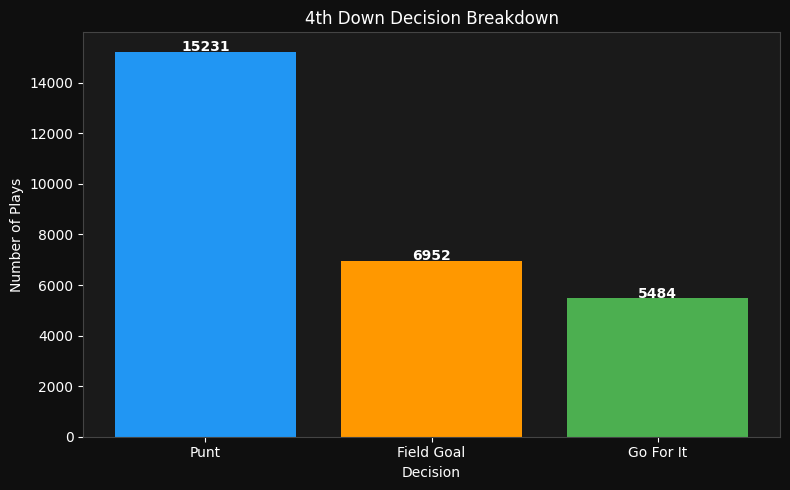

In [12]:
decision_counts = fourth_downs['decision'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(decision_counts.index, decision_counts.values, color=['#2196F3', '#FF9800', '#4CAF50'])
plt.title('4th Down Decision Breakdown')
plt.xlabel('Decision')
plt.ylabel('Number of Plays')

for i, val in enumerate(decision_counts.values):
    plt.text(i, val +20, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

#### Plot 2: 4th Down Decision by Field Position
Breaking decisions down by field zone reveals that coaches are most conservative in their own territory -- which is logically sensical -- but also suggests that they may be leaving value on the field at midfield and in the red zone, where going for it on short yardage oftern has higher expected win probability than punting or kicking a field goal. 

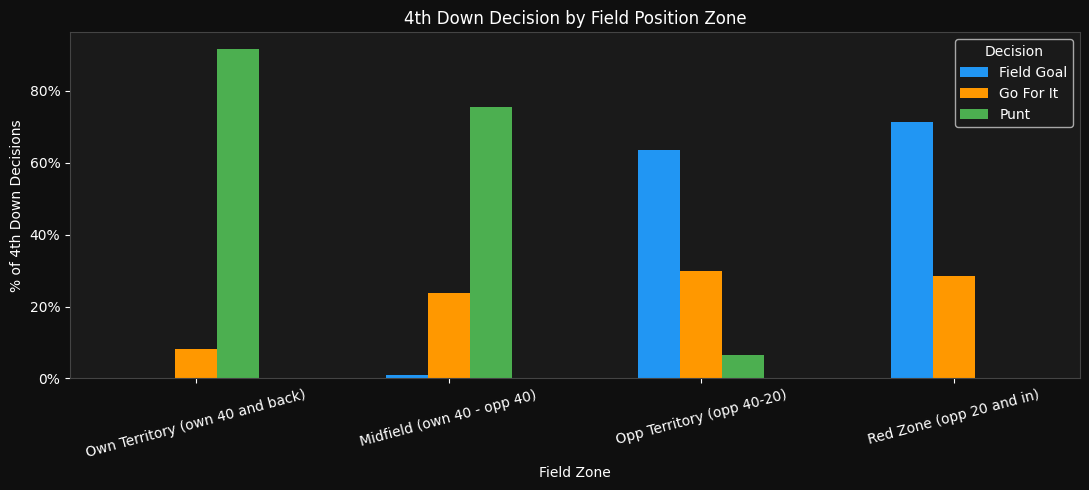

In [13]:
zone_order = [
    'Own Territory (own 40 and back)',
    'Midfield (own 40 - opp 40)', 
    'Opp Territory (opp 40-20)',
    'Red Zone (opp 20 and in)' 
]

zone_pct = zone_counts.div(zone_counts.sum(axis=1), axis=0) * 100
zone_pct = zone_pct.reindex(zone_order)

zone_pct.plot(kind = 'bar', figsize=(11,5), color = ['#2196F3', '#FF9800', '#4CAF50'])
plt.title('4th Down Decision by Field Position Zone')
plt.xlabel('Field Zone')
plt.ylabel('% of 4th Down Decisions')
plt.xticks(rotation=15)
plt.legend(title ='Decision')
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()

## Phase 3: Conversion & Field Goal Probability Models

### 1. 4th Down Conversion Rate When Attempted
To build the recommendation model, we first need to know how likely a "go for it" call on 4th down is to succeed. Across 2019-2025, teams converted roughly 50% of the time. 

However, the overall rate is highly dependent on ydstogo, as expected:
- **4th & 1**: converts around 67% of the time
- **4th & 5**: converts around 48% of the time
- **4th & 10**: converts around 30% of the time

In [14]:
went_for_it = fourth_downs[fourth_downs['decision']=='Go For It'].copy()

print(f"\nTotal plays where team went for it: {len(went_for_it)}")
print(f"Overall conversion rate: {went_for_it['fourth_down_converted'].mean():.1f}")
print(f"\nConversions: {went_for_it['fourth_down_converted'].sum()}")
print(f"Failures: {went_for_it['fourth_down_failed'].sum()}")


Total plays where team went for it: 5484
Overall conversion rate: 0.5

Conversions: 2924.0
Failures: 2557.0


In [15]:
conv_by_ytg = (
    went_for_it.groupby('ydstogo')
    .agg( #mean and count at once
        conv_rate=('fourth_down_converted','mean'),
        n=('fourth_down_converted', 'count')
    )
    .reset_index()
)

conv_by_ytg[conv_by_ytg['n'] >= 10].head(10)

,ydstogo,conv_rate,n
0,1.0,0.670799,2178
1,2.0,0.582921,808
2,3.0,0.511811,508
3,4.0,0.501193,419
4,5.0,0.488818,313
5,6.0,0.396226,212
6,7.0,0.393750,160
7,8.0,0.338129,139
8,9.0,0.271605,81
9,10.0,0.296610,236


#### Plot 3: 4th Down Conversion by YTG

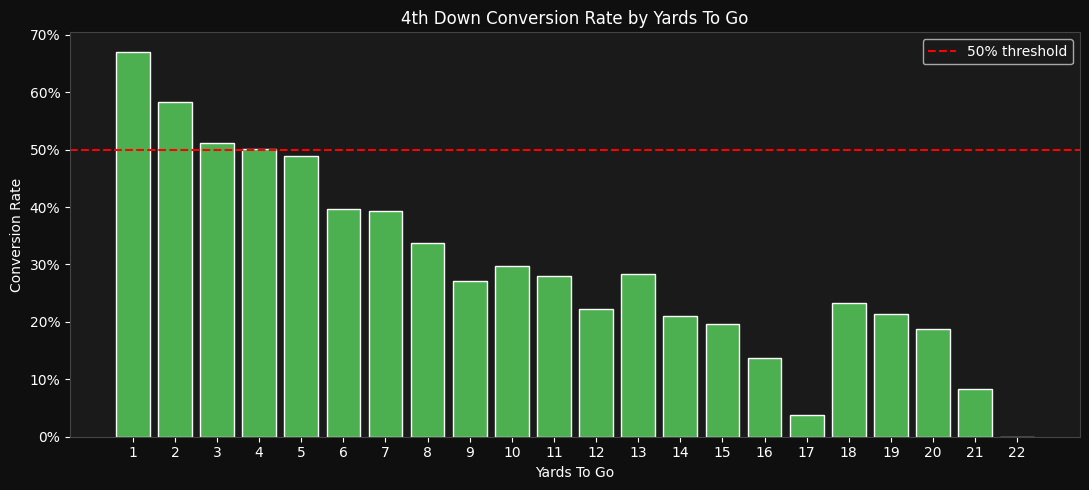

In [16]:
filtered = conv_by_ytg[conv_by_ytg['n'] >= 10]

plt.figure(figsize=(11,5))
plt.bar(filtered['ydstogo'], filtered['conv_rate']*100, color= "#4CAF50", edgecolor="white")
plt.axhline(50, color='red', linestyle='--', linewidth=1.5, label='50% threshold')
plt.title('4th Down Conversion Rate by Yards To Go')
plt.xlabel('Yards To Go')
plt.ylabel('Conversion Rate')
plt.xticks(filtered['ydstogo'])
plt.legend()
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()

### 2. Logistic Regression Model For 4th Down Conversions
To predict whether a 4th down attempt will convert, we trained a logistic regression model (and a random tree model) using four features known before the play call:

- **Yards to go**: a strong predictor -- short distances convert more often
- **Field position**: defenses play differently when protecting a short field
- **Score differential**: affects how aggressively a team may play-call
- **Time remaining**: desparation late in games can change how both sides of the ball may play

The model achieved a ROC-AUC of 0.680, meaning is correctly ranks a converting play above a failing play 68% of the time. Although slightly under acceptable performance (which is .70), football is an inherently unpredictable sport. We tried adding more features such as type of terrain they played on (articial v. grass) and indoor v. outdoor facility, but it made neglible impact on the ROC-AUC, so it was removed from the model for a cleaner presentation and easier explainability. 

So, this 4-feature model capturing the core situational factors is accurate enough to be used in tandem with professional coach play-calling and knowledge, as well as clear enough to present.

In [17]:
features = [
    'ydstogo',
    'yardline_100', 
    'score_differential',
    'game_seconds_remaining'
]

# ydstogo -- shorter = easier
# yardline_100 -- defenses play differently in different field positions
# score_differential -- affects how both teams play call
# game_seconds_remaining -- desperation late in games changes dynamic

model_data = went_for_it[features + ['fourth_down_converted']].dropna()

x = model_data[features]
y = model_data['fourth_down_converted']

print(f"Training samples: {len(x)}")
print(f"Features: {features}")

Training samples: 5484
Features: ['ydstogo', 'yardline_100', 'score_differential', 'game_seconds_remaining']


#### Model Evaluation
The model was evaluated on a held-out test set - 20% of plays that were not used during training. This is to see how well the model generalizes to new situations it hasn't seen before. 

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) #splits data 80-20 train test, 20 will be used to evaluate accuracy of model #random_state = 42 just sets a seed so we get same split every time

scaler = StandardScaler() #scales all features to the same range -- LogisticRegression is sensitive to features being on different scales, i.e. ydstogo is 1-20 but game_seconds_remaining 0-3600
x_train_scaled = scaler.fit_transform(x_train) #fit -- learns the stats of data, i.e. mean & sd of each column, 
x_test_scaled = scaler.transform(x_test) #transform -- uses stats (mean & sd) to scale the data

# For StandardScaler, scaled_value = (original - mean) / standard_deviation

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(x_train_scaled, y_train)

print("Model trained!")

y_pred = model.predict(x_test_scaled) #runs test data through model, hard prediction for each play: 1=converts, 0=fails
y_prob = model.predict_proba(x_test_scaled)[: ,1] #runs test data through model, returns likelihood of converting. [: ,1] grads second column: converts column

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.1%}") #compares models hard predictions against actual outcomes
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3}") #measures how well model ranks outcomes-- ROC of 1 is perfect, 0.5 is random guessing in this case

Model trained!

Accuracy: 64.6%
ROC-AUC: 0.68


In [19]:
#Not important for the model, but wanted to compare Random Forest model to the Logistic Regression that we will be using in terms of ROC-AUC

random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(x_train_scaled, y_train)

y_pred_rf = random_forest_model.predict(x_test_scaled)
y_prob_rf = random_forest_model.predict_proba(x_test_scaled)[: ,1]

print(f"\nAccuracy: {accuracy_score(y_test, y_pred_rf):.1%}") #compares models hard predictions against actual outcomes
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.3}") #measures how well model ranks outcomes-- ROC of 1 is perfect, 0.5 is random guessing in this case


Accuracy: 57.8%
ROC-AUC: 0.602


In [20]:
test_df = pd.DataFrame(
    {'True': y_test, 'Logistic': y_prob, 'RandomForest': y_prob_rf}
)

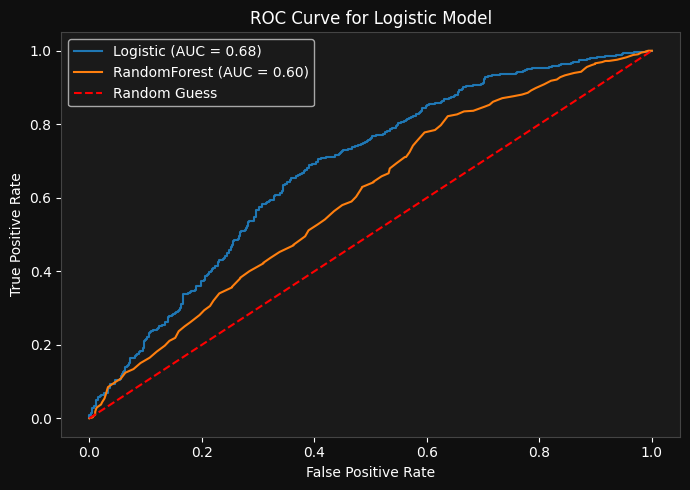

In [21]:
plt.figure(figsize=(7,5))

for type_model in ['Logistic', 'RandomForest']:
    fpr, tpr, _ = roc_curve(test_df['True'], test_df[type_model])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{type_model} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'r--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Model')
plt.legend()

plt.tight_layout()
plt.show()

### 3. Field Goal Make Probability by Distance
Kickers tend to be highly accurate inside 35 yards, with a small drop-off in performance between 35 and 50 yards, and then a sharper drop-off outside of 50 yards. This is quite important for a decision framework -- in some scenarios, a 55-yard field goal attempt may have a lower expected win probability than going for it on 4th down, as depending on ydstogo, converting and making the field goal may have similar probabilities.

In [22]:
fg_plays = pbp[
    (pbp['play_type'] =='field_goal') &
    (pbp['field_goal_result'].isin(['made', 'missed']))
].copy()

fg_plays['made'] = (fg_plays['field_goal_result'] == 'made').astype(int)

print(f"Total field goal attempts: {len(fg_plays)}")
print(f"Overall make rate: {fg_plays['made'].mean():.1%}")

Total field goal attempts: 7489
Overall make rate: 86.3%


In [23]:
fg_plays['dist_bin'] = (fg_plays['kick_distance'] // 5) * 5 #// is floor divisor, so, rounding each distance to the nearest 5 yd bin.

fg_by_dist = (
    fg_plays.groupby('dist_bin')
    .agg(
        make_rate=('made', 'mean'),
        n=('made', 'count')
    )
    .reset_index()
    .query('n >= 10')
)

fg_by_dist

,dist_bin,make_rate,n
0,15.0,1.000000,25
1,20.0,0.994374,711
2,25.0,0.975435,977
3,30.0,0.966926,1028
4,35.0,0.925303,1071
5,40.0,0.837294,1094
6,45.0,0.771800,1078
7,50.0,0.741840,1011
8,55.0,0.624402,418
9,60.0,0.474576,59


#### Plot 4: Field Goal Make Rate by Distance

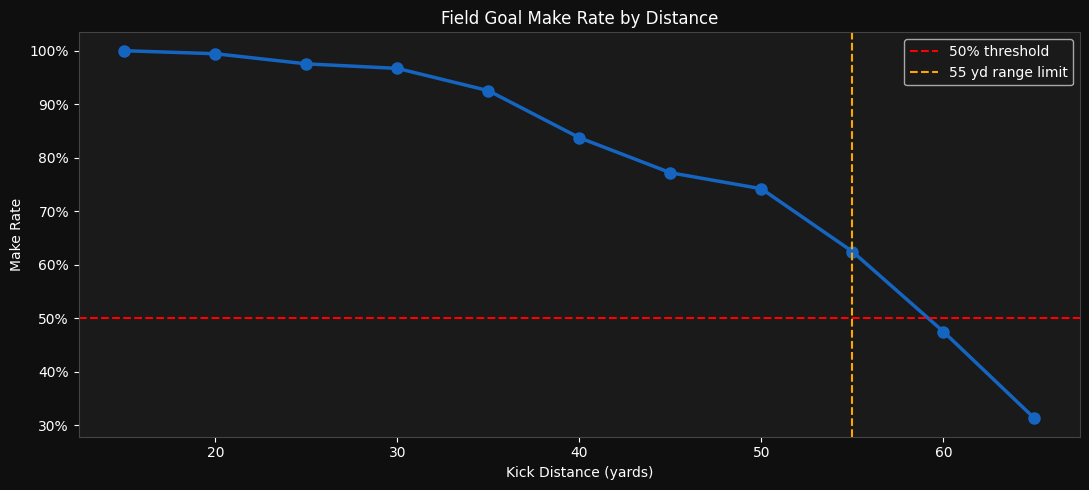

In [24]:
plt.figure(figsize=(11,5))
plt.plot(fg_by_dist['dist_bin'], fg_by_dist['make_rate']*100,
        'o-', color='#1565C0', linewidth=2.5, markersize=8)
plt.axhline(50, color = 'red', linestyle='--', linewidth=1.5, label='50% threshold')
plt.axvline(55, color = 'orange', linestyle='--', linewidth=1.5, label='55 yd range limit')
plt.title('Field Goal Make Rate by Distance')
plt.xlabel('Kick Distance (yards)')
plt.ylabel('Make Rate')
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter())
plt.legend()

plt.tight_layout()
plt.show()


## Phase 4: 4th Down Decision Framework
The conversion model alone doesn't recommend what to do -- it just tells us the probability of success if we go for it. To make an actual recommendation, we compare this expected outcome (expected win probability) of all three options: go for it, punt, and kick a field goal. The recommendation is then simply whichever option produces the highest expected win probability. 

The win probability values after each outcome are derived from derived from historical averages in the play-by-play data, grouped by field position, score differential, and time remaining. This ensures the framework is data-driven, but is also a balancing act to prevent under/over grouping. For example, this framework bins 0-2min remaining rather than 0-1min and 1-2min, even though play calls in those time spans would likely be different. This is because binning 0-1min and 1-2min would lead to small bin (<10) sizes when grouped with the score bin, and that is not enough data to reliably recommend a decision. 

#### Building the Lookup Tables
For each possible outcome, we calculate the average win probability that followed similar historical situations. Grouping by score differential and time remaining bins ensures the lookup relfects the actual pressure/urgency of the game state. For example, a punt with 60 seconds left down 7 should have a very different EWP than a punt in the first quarter of a tied game. 

In [25]:
#1. WP after going for it (success v. failure)
went_for_it['wp_after'] = went_for_it['wp'] + went_for_it['wpa']

conv_wp_table = (
    went_for_it.groupby(['ydstogo', 'fourth_down_converted'])
    ['wp_after'].mean().reset_index()
    .rename(columns={'wp_after': 'avg_wp_after_conv'})
)

#Need to bin conv according to time remaining and score differential--without context awareness, go for it is artificially low
went_for_it['yardline_bin'] = (went_for_it['yardline_100']//5) * 5

went_for_it['time_bin'] = pd.cut(
    went_for_it['game_seconds_remaining'],
    bins=[0, 120, 300, 900, 1800, 3600],
    labels=['0-2min', '2-5min', '5-15min', '15-30min', '30min+']
)

went_for_it['score_bin'] = pd.cut(
    went_for_it['score_differential'],
    bins=[-100, -15, -8, -1, 0, 7, 14, 100],
    labels=['down 15+', 'down 8-14', 'down 1-7', 'tied', 'up 1-7', 'up 8-14', 'up 15+']
)

conv_wp_table2 = (
    went_for_it.groupby(['ydstogo', 'fourth_down_converted', 'yardline_bin', 'time_bin', 'score_bin'])
    ['wp_after'].mean().reset_index()
    .rename(columns={'wp_after': 'avg_wp_after_conv'})
)

#2. WP after punt by field position
punts = fourth_downs[fourth_downs['decision']=='Punt'].copy()
punts['wp_after'] = punts['wp'] + punts['wpa']
punts['yardline_bin'] = (punts['yardline_100']//10) * 10

punt_wp_table = (
    punts.groupby('yardline_bin')
    ['wp_after'].mean().reset_index()
    .rename(columns={'wp_after': 'avg_wp_after_punt'})
)

#Need to bin punts according to time remaining and score differential--without context awareness, WP after punt is artificially high
punts['time_bin'] = pd.cut(
    punts['game_seconds_remaining'],
    bins=[0, 120, 300, 900, 1800, 3600],
    labels=['0-2min', '2-5min', '5-15min', '15-30min', '30min+']
)

punts['score_bin'] = pd.cut(
    punts['score_differential'],
    bins=[-100, -15, -8, -1, 0, 7, 14, 100],
    labels=['down 15+', 'down 8-14', 'down 1-7', 'tied', 'up 1-7', 'up 8-14', 'up 15+']
)

punt_wp_table2 = (
    punts.groupby(['yardline_bin', 'time_bin', 'score_bin'])
    ['wp_after'].mean().reset_index()
    .rename(columns={'wp_after': 'avg_wp_after_punt'})
)


#3. WP after field goal (made v. missed)
fgs = fourth_downs[fourth_downs['decision'] == 'Field Goal'].copy()
fgs['wp_after'] = fgs['wp'] + fgs['wpa'] 
fgs['made'] = (fgs['field_goal_result'] == 'made').astype(int)
fgs['dist_bin'] = (fgs['kick_distance'] // 5) * 5

fg_wp_table = (
    fgs.groupby(['dist_bin', 'made'])
    ['wp_after'].mean().reset_index()
    .rename(columns={'wp_after': 'avg_wp_after_fg'})
)

#Can't tell if fg WP is inflated or deflated without binning for time and score, but binning anyway for consistency. 
fgs['time_bin'] = pd.cut(
    fgs['game_seconds_remaining'],
    bins=[0, 120, 300, 900, 1800, 3600],
    labels=['0-2min', '2-5min', '5-15min', '15-30min', '30min+']
)

fgs['score_bin'] = pd.cut(
    fgs['score_differential'],
    bins=[-100, -15, -8, -1, 0, 7, 14, 100],
    labels=['down 15+', 'down 8-14', 'down 1-7', 'tied', 'up 1-7', 'up 8-14', 'up 15+']
)

fg_wp_table2 = (
    fgs.groupby(['dist_bin', 'made', 'time_bin', 'score_bin'])
    ['wp_after'].mean().reset_index()
    .rename(columns={'wp_after': 'avg_wp_after_fg'})
)

print("Lookup tables built!")
print(f"\nConvert WP table: {len(conv_wp_table2)} entries")
print(f"Punt WP table: {len(punt_wp_table2)} entries")
print(f"Field Goal WP table: {len(fg_wp_table2)} entries")

Lookup tables built!

Convert WP table: 2934 entries
Punt WP table: 229 entries
Field Goal WP table: 485 entries


#### Decision Framework Logic for recommend_4th_down Function:

For any 4th down situation, we're going to calculate the Expected Win Probability (EWP) for all three options and recommend whichever is highest: 

EWP(go) = P(convert) x WP_if_success + (1-P(convert)) x WP_if_failure
EWP(field_goal) = P(make) x WP_if_made + (1-P(make)) x WP_if_miss
EWP(punt) = WP_after_punt

P(convert) we already have from our logistic regression

P(make) we have from fg_by_dist table

We get WP from the historical averages in the play_by_play data

In [26]:
def recommend_4th_down(ydstogo, yardline_100, score_differential, game_seconds_remaining, verbose = True):
    #1. Predict conversion probability
    situation = pd.DataFrame([{
        'ydstogo': ydstogo,
        'yardline_100': yardline_100,
        'score_differential': score_differential,
        'game_seconds_remaining': game_seconds_remaining
    }])
    #scale situation data, as in the training of Logistic Regression model, and then run the scaled data through regression to predict probability of converting
    p_convert = model.predict_proba(scaler.transform(situation[features]))[0][1] #first (and only), second probability (prob. of converting)

    #2. Expected WP: Go for it
    ytg = min(int(ydstogo), 10)

    yl_bin = (yardline_100 // 5) * 5

    time_bin = pd.cut(
        [game_seconds_remaining],
        bins=[0, 120, 300, 900, 1800, 3600],
        labels=['0-2min', '2-5min', '5-15min', '15-30min', '30min+']
    )[0]

    score_bin = pd.cut(
        [score_differential],
        bins=[-100, -15, -8, -1, 0, 7, 14, 100],
        labels=['down 15+', 'down 8-14', 'down 1-7', 'tied', 'up 1-7', 'up 8-14', 'up 15+']
    )[0]

    #filters for desired game situation
    wp_success = conv_wp_table2.loc[
        (conv_wp_table2['yardline_bin'] == yl_bin) &
        (conv_wp_table2['time_bin'] == time_bin) &
        (conv_wp_table2['score_bin'] == score_bin) & 
        (conv_wp_table2['ydstogo'] == ytg) &
        (conv_wp_table2['fourth_down_converted'] == 1), 'avg_wp_after_conv'].values #after filtering for matching row, takes avg_wp_after_conv from that row
    wp_failure = conv_wp_table2.loc[
        (conv_wp_table2['yardline_bin'] == yl_bin) &
        (conv_wp_table2['time_bin'] == time_bin) &
        (conv_wp_table2['score_bin'] == score_bin) & 
        (conv_wp_table2['ydstogo'] == ytg) &
        (conv_wp_table2['fourth_down_converted'] == 0), 'avg_wp_after_conv'].values
    wp_success = wp_success[0] if len(wp_success) > 0 else 0.65
    wp_failure = wp_failure[0] if len(wp_failure) > 0 else 0.35

    ewp_go = p_convert * wp_success + (1-p_convert) * wp_failure

    #3. Expected WP: Punt
    yl_bin = (yardline_100 // 10) * 10

    time_bin = pd.cut(
        [game_seconds_remaining],
        bins=[0, 120, 300, 900, 1800, 3600],
        labels=['0-2min', '2-5min', '5-15min', '15-30min', '30min+']
    )[0]

    score_bin = pd.cut(
        [score_differential],
        bins=[-100, -15, -8, -1, 0, 7, 14, 100],
        labels=['down 15+', 'down 8-14', 'down 1-7', 'tied', 'up 1-7', 'up 8-14', 'up 15+']
    )[0]
    
    wp_punt = punt_wp_table2.loc[
        (punt_wp_table2['yardline_bin'] == yl_bin) &
        (punt_wp_table2['time_bin'] == time_bin) &
        (punt_wp_table2['score_bin'] == score_bin), 'avg_wp_after_punt'].values
    
    ewp_punt = wp_punt[0] if len(wp_punt) > 0 else 0.45

    #4. Expected WP: Field Goal
    fg_dist = yardline_100 + 17
    dist_bin = (fg_dist // 5) * 5
    p_make = fg_by_dist.loc[fg_by_dist['dist_bin'] == dist_bin, 'make_rate'].values
    p_make = p_make[0] if len(p_make) > 0 else max(0.1, 1-fg_dist / 70)

    time_bin = pd.cut(
        [game_seconds_remaining],
        bins=[0, 120, 300, 900, 1800, 3600],
        labels=['0-2min', '2-5min', '5-15min', '15-30min', '30min+']
    )[0]

    score_bin = pd.cut(
        [score_differential],
        bins=[-100, -15, -8, -1, 0, 7, 14, 100],
        labels=['down 15+', 'down 8-14', 'down 1-7', 'tied', 'up 1-7', 'up 8-14', 'up 15+']
    )[0]

    wp_made = fg_wp_table2.loc[
        (fg_wp_table2['dist_bin'] == dist_bin) & 
        (fg_wp_table2['time_bin'] == time_bin) & 
        (fg_wp_table2['score_bin'] == score_bin) & 
        (fg_wp_table2['made'] == 1), 'avg_wp_after_fg'].values
    wp_missed = fg_wp_table2.loc[
        (fg_wp_table2['dist_bin'] == dist_bin) & 
        (fg_wp_table2['time_bin'] == time_bin) & 
        (fg_wp_table2['score_bin'] == score_bin) & 
        (fg_wp_table2['made'] == 0), 'avg_wp_after_fg'].values
    wp_made = wp_made[0] if len(wp_made) > 0 else 0.60
    wp_missed = wp_missed[0] if len(wp_missed) > 0 else 0.38

    ewp_fg = p_make * wp_made + (1-p_make) * wp_missed

    #5. Recommend Best Option
    options = {'Go For It': float(ewp_go),'Punt': float(ewp_punt), 'Field Goal': float(ewp_fg)}
    best = max(options, key = options.get)

    field_pos = f"opp {yardline_100}" if yardline_100 <= 50 else f"own{100 - yardline_100}"

    if verbose:
        print(f"4th & {ydstogo} | Yardline: {field_pos} | Score: {int(score_differential):+d} | {game_seconds_remaining //60} mins left")
        print(f" Conversion probability: {p_convert:.1%}")
        print(f" Go For it: EWP = {ewp_go:.3f}")
        print(f" Punt: EWP = {ewp_punt:.3f}")
        print(f" Field Goal: EWP = {ewp_fg:.3f}")

        print(f"\n Recommendation: {best}")

    return options


### Testing the function:

In [27]:
#Scenario 1: Short yardage, opponent territory, tied game
recommend_4th_down(
    ydstogo = 1, 
    yardline_100 = 35, 
    score_differential = 0, 
    game_seconds_remaining = 1200
)

4th & 1 | Yardline: opp 35 | Score: +0 | 20 mins left
 Conversion probability: 64.3%
 Go For it: EWP = 0.543
 Punt: EWP = 0.508
 Field Goal: EWP = 0.567

 Recommendation: Field Goal


{'Go For It': 0.5428656660203418,
 'Punt': 0.5079120993614197,
 'Field Goal': 0.5674032030234705}

In [28]:
#Scenario 2: long yardage, own terrority, losing late
recommend_4th_down(
    ydstogo = 8, 
    yardline_100=60,
    score_differential = -7,
    game_seconds_remaining = 120
)

4th & 8 | Yardline: own40 | Score: -7 | 2 mins left
 Conversion probability: 38.8%
 Go For it: EWP = 0.273
 Punt: EWP = 0.450
 Field Goal: EWP = 0.402

 Recommendation: Punt


{'Go For It': 0.2727874971973556, 'Punt': 0.45, 'Field Goal': 0.402}

In [29]:
#Scenario 3: Short time, down 7, redzone
recommend_4th_down(
    ydstogo=3, 
    yardline_100=15, 
    score_differential=-7, 
    game_seconds_remaining = 120
)

4th & 3 | Yardline: opp 15 | Score: -7 | 2 mins left
 Conversion probability: 52.7%
 Go For it: EWP = 0.508
 Punt: EWP = 0.450
 Field Goal: EWP = 0.622

 Recommendation: Field Goal


{'Go For It': 0.5082290814824256,
 'Punt': 0.45,
 'Field Goal': 0.6224016630146927}

## Phase 5: 4th Down Decisions by Coach
With the recommendation framework built, we can evaluate every 4th down decision in our dataset and compare it to what the model would have recommended. This tells us which coaches are most and least aligned with analytically optimal decision-making. 

Key findings: 
- League-wide, coaches on average only matched the model's recommendation 43.7% of the time, meaning the majority of the 4th down decisions leave win probability on the field
- Newer, analytically-minded coaches like **Liam Coen** top the leaderboard
- More emotional decision makers, such as **Aaron Glenn**, live at the bottom of the leaderboard

It is worth noting that this analysis has limitations -- the model doesn't account for personnel, injuries, weather on specific plays, or other contextual factors a coach might reasonably consider. A coach deviating from the model is not necessarily *wrong* by any means. However, strong deviation across seasons could imply suboptimal decision-making, in accordance with historical data.

In [30]:
print([col for col in pbp.columns if 'coach' in col.lower()])

['home_coach', 'away_coach']


In [31]:
pbp[['posteam', 'home_team', 'away_team', 'home_coach', 'away_coach']].dropna().head(10)

,posteam,home_team,away_team,home_coach,away_coach
1,ATL,MIN,ATL,Mike Zimmer,Dan Quinn
2,ATL,MIN,ATL,Mike Zimmer,Dan Quinn
3,ATL,MIN,ATL,Mike Zimmer,Dan Quinn
4,ATL,MIN,ATL,Mike Zimmer,Dan Quinn
5,ATL,MIN,ATL,Mike Zimmer,Dan Quinn
6,MIN,MIN,ATL,Mike Zimmer,Dan Quinn
7,MIN,MIN,ATL,Mike Zimmer,Dan Quinn
8,MIN,MIN,ATL,Mike Zimmer,Dan Quinn
9,MIN,MIN,ATL,Mike Zimmer,Dan Quinn
10,ATL,MIN,ATL,Mike Zimmer,Dan Quinn


In [32]:
#format coach of team with possession 
def get_coach(row):
        if row['posteam'] == row['home_team']:
            return row['home_coach']
        else:
            return row['away_coach']

pbp['pos_coach'] = pbp.apply(get_coach, axis=1) #iterate function over rows rather than columns

In [33]:
pbp[['posteam', 'home_team', 'pos_coach']].dropna().head(10)

,posteam,home_team,pos_coach
1,ATL,MIN,Dan Quinn
2,ATL,MIN,Dan Quinn
3,ATL,MIN,Dan Quinn
4,ATL,MIN,Dan Quinn
5,ATL,MIN,Dan Quinn
6,MIN,MIN,Mike Zimmer
7,MIN,MIN,Mike Zimmer
8,MIN,MIN,Mike Zimmer
9,MIN,MIN,Mike Zimmer
10,ATL,MIN,Dan Quinn


In [34]:
fourth_downs['pos_coach']=pbp.loc[fourth_downs.index, 'pos_coach']

fourth_downs['pos_coach'].value_counts().head()

pos_coach
Mike Tomlin        916
Sean McVay         890
Zac Taylor         859
Kevin Stefanski    833
Andy Reid          814
Name: count, dtype: int64

In [35]:
row = fourth_downs.iloc[0]

#run recommend_4th_down on one of the rows of fourth_downs
result = recommend_4th_down(
    ydstogo=row['ydstogo'],
    yardline_100=row['yardline_100'],
    score_differential=row['score_differential'],
    game_seconds_remaining=row['game_seconds_remaining'],
    verbose = False
)

print("Result:", result)
print("Type:", type(result))

best = max(result, key=result.get)
print("Best:", best)

record = { #adds new dictionary to our records list for the play with coach, decision, recommended decision, and if coach followed recommendation
            'pos_coach': row['pos_coach'],
            'actual': row['decision'],
            'recommended': best,
            'followed_model': row['decision'] == best
}

print("Record:", record)

Result: {'Go For It': 0.3944039712337625, 'Punt': 0.47434056171735595, 'Field Goal': 0.402}
Type: <class 'dict'>
Best: Punt
Record: {'pos_coach': 'Dan Quinn', 'actual': 'Punt', 'recommended': 'Punt', 'followed_model': True}


In [36]:
#create empty list
records = [] 

for idx, row in fourth_downs.iterrows(): #row index number & row
    try: 
        result = recommend_4th_down( #runs function on row
            ydstogo=row['ydstogo'],
            yardline_100=row['yardline_100'],
            score_differential=row['score_differential'],
            game_seconds_remaining=row['game_seconds_remaining'],
            verbose=False
        )
        best = max(result, key=result.get) #returns whether go for it, punt, or field goal has the highest EWP
        records.append({ #adds new dictionary to our records list for the play with coach, decision, recommended decision, and if coach followed recommendation
            'pos_coach': row['pos_coach'],
            'actual': row['decision'],
            'recommended': best,
            'followed_model': row['decision'] == best
        })
    except Exception: #skips any play that throws an error
        pass

results_df = pd.DataFrame(records)
print(f"Evaluated {len(results_df):,} plays")
print(f"League-wide % matching model: {results_df['followed_model'].mean():.1%}")


Evaluated 27,667 plays
League-wide % matching model: 43.7%


#### Coach Leaderboard
Only coaches with 50 or more 4th down decisions are included, ensuring the percentages are statistically meaningful rather than skewed by a small number of plays. 

In [37]:
coach_stats = (
    results_df.groupby('pos_coach')
    .agg(
        fourth_downs_called=('actual', 'count'),
        pct_optimal=('followed_model', 'mean')
    )
    .reset_index()
    .query('fourth_downs_called >= 50') #filter out coached with less than 50 play calls
    .sort_values('pct_optimal', ascending=False)
    .reset_index(drop=True)
)

coach_stats['pct_optimal']=coach_stats['pct_optimal'] * 100
coach_stats.head()

,pos_coach,fourth_downs_called,pct_optimal
0,Liam Coen,122,59.016393
1,Mike Macdonald,250,56.000000
2,Nick Sirianni,635,55.590551
3,Kyle Shanahan,788,55.583756
4,Andy Reid,814,55.528256


#### Plot 5: Coaches by Optimality of 4th Down Decisions

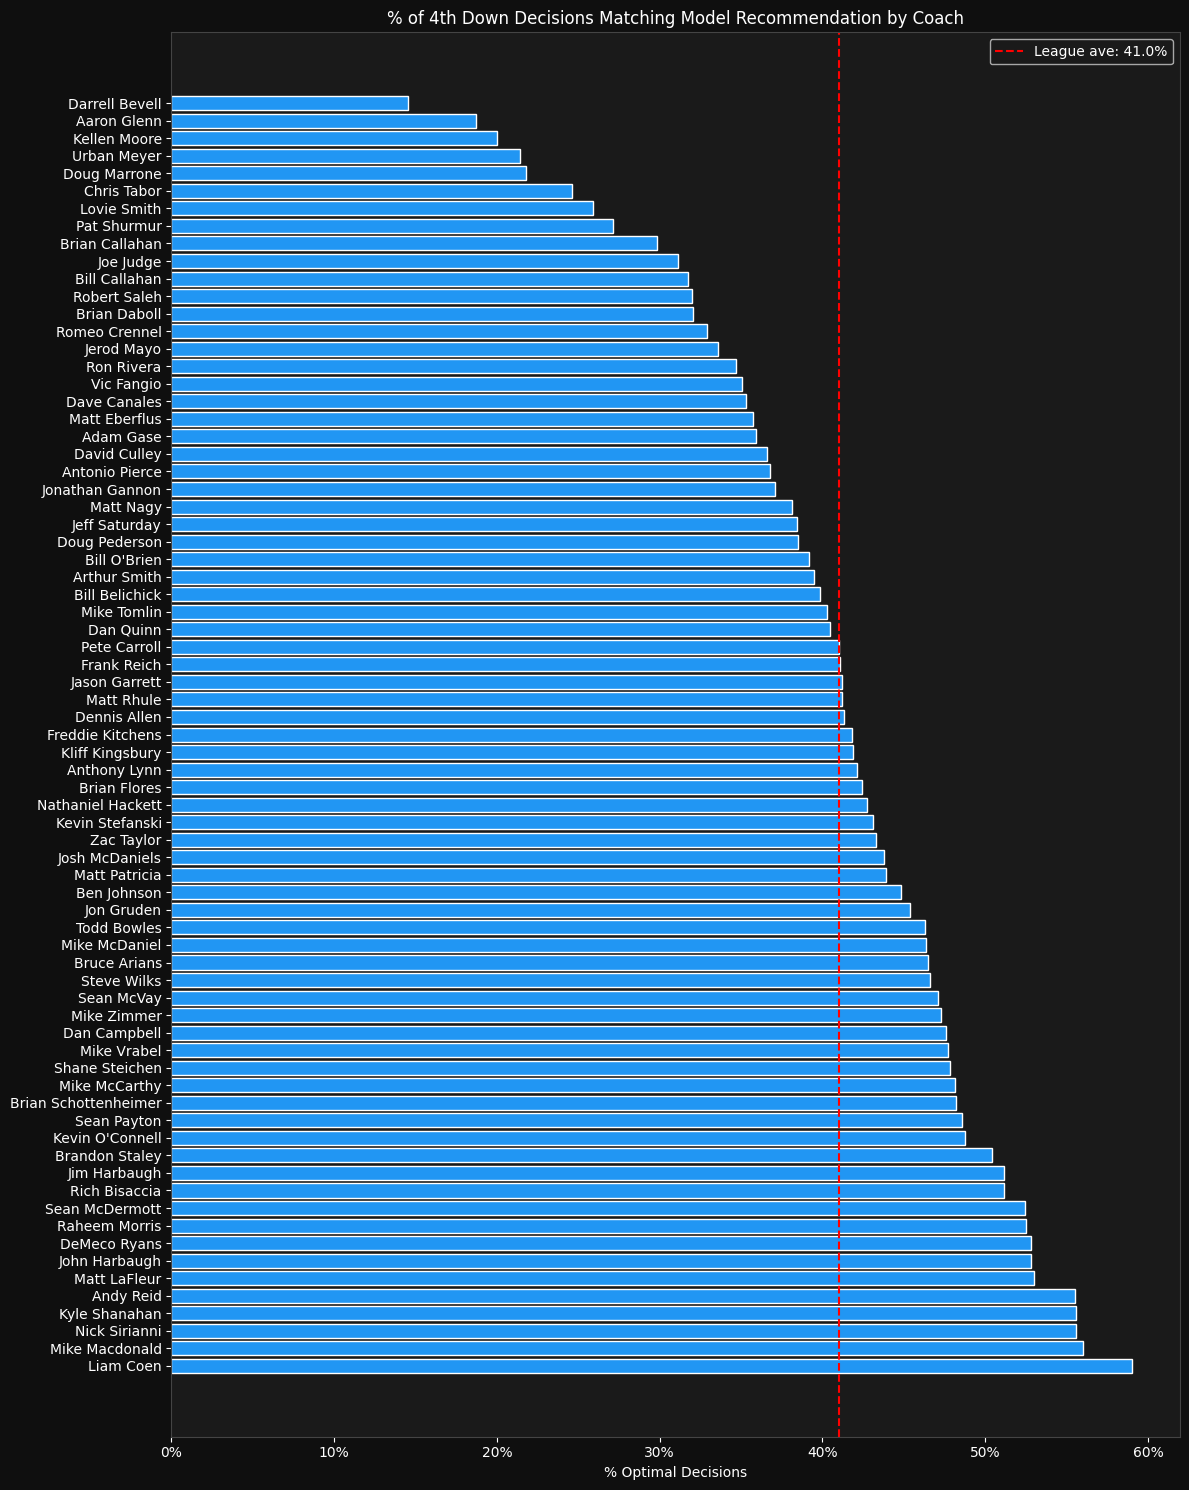

In [38]:
plt.figure(figsize=(12,15))
plt.barh(coach_stats['pos_coach'], coach_stats['pct_optimal'],
         color='#2196F3', edgecolor='white')

league_avg = coach_stats['pct_optimal'].mean()
plt.axvline(league_avg, color='red', linestyle='--', linewidth=1.5,
            label=f'League ave: {league_avg:.1f}%')

plt.title('% of 4th Down Decisions Matching Model Recommendation by Coach')
plt.xlabel('% Optimal Decisions')
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter())
plt.legend()

plt.tight_layout()
plt.show()

## Conclusion
This project built a complete 4th down decision framework using nflreadpy open-source data, replicating the kind of analysis performed by NFL analytics teams. 

### Key Takeaways
- NFL coaches match the analytically optimal solution only **43.7%** of the time
- There is strong reason to believe that **yards to go** is the single strongest predictor of conversion success
- This analysis suggests that the NFL as a whole is systematically too conservative in its play-calling, particularly at midfiled on short yardage 4th down situations
- Younger coaches, such as Liam Coen, Mike Macdonald, and Nick Sirianni tend to align with analytically correct decision-making on 4th down

### Limitations & Next Steps
- The model only uses 4 features. However, way more than 4 features play into a 4th down game state. Defensive strength, offensive personnel, and weather for outdoor games are all possible considerations before making a play call. Adding some/all of these features to the model could improve accuracy. 
- A more sophisticated model could better predict outcomes that the Logistic Regression misses
- The coach leaderboard should not be used in a way that confuses situation quality with decision quality -- if possible, a future version would want to control for the situations each coach faced with regard to personnel and game dynamic